In [1]:
import sys

# ruta_raiz = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/'
ruta_raiz = '/Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/' # Ruta en el mac
sys.path.append(ruta_raiz)

from RRAM import Plot_PostProcess as pplt
from RRAM import Constants as cte

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%load_ext autoreload
%autoreload 2

In [2]:
data_path_pp_set = ruta_raiz + 'Results/set/resultados_pp_set_0.csv'
data_path_sp_set = ruta_raiz + 'Results/set/resultados_sp_set_0.csv'
data_path_pp_reset = ruta_raiz + 'Results/reset/resultados_pp_reset_0.csv'
data_path_sp_reset = ruta_raiz + 'Results/reset/resultados_sp_reset_0.csv'

data_full = ruta_raiz + 'Results/Datos_Simulacion_completa.csv'

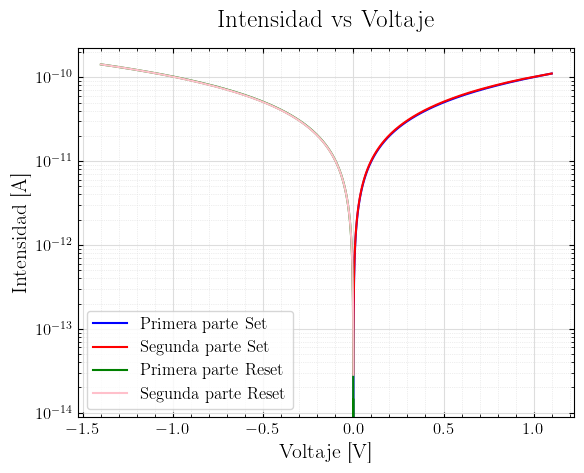

In [3]:
df_pset = pd.read_csv(data_path_pp_set, dtype=float)
df_sset = pd.read_csv(data_path_sp_set, dtype=float)
df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)

global_tittle = 'Intensidad vs Voltaje'
save_path = ruta_raiz + 'Results\Grafico_Intensidad_Voltaje'

i_ps = np.array(df_pset['Intensidad [A]'])
i_ss = np.array(df_sset['Intensidad [A]'])
i_pr = np.array(df_preset['Intensidad [A]'])
i_sr = np.array(df_sreset['Intensidad [A]'])

v_ps = np.array(df_pset['Voltaje [V]'])
v_ss = np.array(df_sset['Voltaje [V]'])
v_pr = np.array(df_preset['Voltaje [V]'])
v_sr = np.array(df_sreset['Voltaje [V]'])

fig, axes = plt.subplots()
pplt.config_ax(axes)

axes.set_xlabel('Voltaje [V]')
axes.set_ylabel('Intensidad [A]')

axes.set_yscale('log')

axes.set_title(global_tittle, fontsize=18, pad=15)
axes.plot(v_ps, i_ps, color='blue', label='Primera parte Set')
axes.plot(v_ss, i_ss, color='red', label='Segunda parte Set')
axes.plot(v_pr, i_pr, color='green', label='Primera parte Reset')
axes.plot(v_sr, i_sr, color='pink', label='Segunda parte Reset')

plt.legend()
plt.show()
# fig.savefig(save_path + '.pdf', bbox_inches='tight')

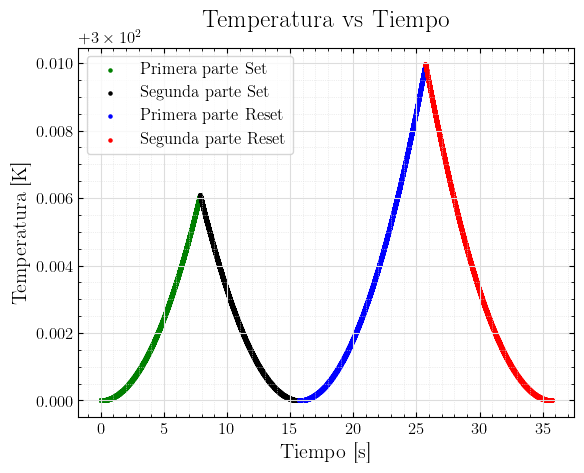

In [4]:
temperature_ps = np.array(df_pset['Temperatura [K]'])
temperature_ss = np.array(df_sset['Temperatura [K]'])
temperature_pr = np.array(df_preset['Temperatura [K]'])
temperature_sr = np.array(df_sreset['Temperatura [K]'])

tiempo_ps = np.array(df_pset['# Tiempo simulacion [s]'])
tiempo_ss = np.array(df_sset['# Tiempo simulacion [s]'])
tiempo_pr = np.array(df_preset['# Tiempo simulacion [s]'])
tiempo_sr = np.array(df_sreset['# Tiempo simulacion [s]'])

fig, axes = plt.subplots()
pplt.config_ax(axes)

axes.set_xlabel('Tiempo [s]')
axes.set_ylabel('Temperatura [K]')

axes.set_title('Temperatura vs Tiempo', fontsize=18, pad=15)

axes.scatter(tiempo_ps, temperature_ps, color='green', label='Primera parte Set', s = 5)
axes.scatter(tiempo_ss, temperature_ss, color='black', label='Segunda parte Set', s = 5)
axes.scatter(tiempo_pr, temperature_pr, color='blue', label='Primera parte Reset', s = 5)
axes.scatter(tiempo_sr, temperature_sr, color='red', label='Segunda parte Reset', s = 5)

plt.legend()
plt.show()

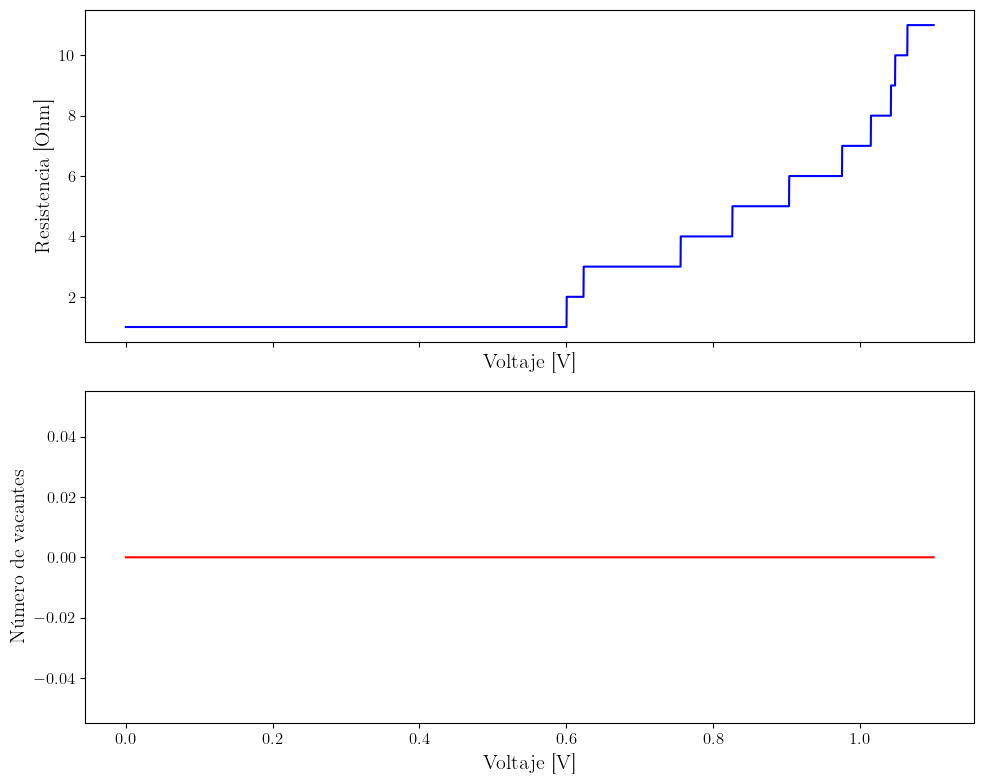

In [5]:
# Cargar los datos desde el archivo de texto, omitiendo la primera fila (encabezado)
data = np.loadtxt(ruta_raiz + 'Results/set/Vacantes_resistencia_0.txt', skiprows=1)

# El archivo tiene cuatro columnas: tiempo de simulación, voltaje resitencia y número de vacantes
tiempo = data[:, 0]
voltaje = data[:, 1]
resistencia = data[:, 2]
num_vacantes = data[:, 3]

# Crear una figura y ejes para las gráficas
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Graficar cada columna en un subplot diferente
axs[0].plot(voltaje, resistencia, label='Resistencia [Ohm]', color='blue')
axs[0].set_ylabel('Resistencia [Ohm]')
axs[0].set_xlabel('Voltaje [V]')

axs[1].plot(voltaje, num_vacantes, label='Numero de vacantes', color='red')
axs[1].set_ylabel('Número de vacantes')
axs[1].set_xlabel('Voltaje [V]')

# Ajustar el espacio entre los subplots
plt.tight_layout()

# Mostrar la gráfica
plt.show()
